In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from scripts import indices, visual

### Fig S6.1: connectedness, efficiency & number of hubs

In [2]:
f = open('../Output/Stoch/rand_cp_stb.pckl', 'rb')
connected_pairs_rand = pickle.load(f)
f.close()

f = open('../Output/Stoch/rand_eff_stb.pckl', 'rb')
rand_eff = pickle.load(f)
f.close()

thresh = 15
f = open('../Output/Stoch/rand_hubs_'+str(thresh)+'_stb.pckl', 'rb')
Hubs_rand = pickle.load(f)
f.close()

In [3]:
f = open('../Output/Stoch/dist_cp_stb.pckl', 'rb')
connected_pairs_dist = pickle.load(f)
f.close()

f = open('../Output/Stoch/dist_eff_stb.pckl', 'rb')
dist_eff = pickle.load(f)
f.close()

thresh = 15
f = open('../Output/Stoch/dist_hubs_'+str(thresh)+'_stb.pckl', 'rb')
Hubs_dist = pickle.load(f)
f.close()

In [8]:
f = open('../Output/Determ/rand_cp_stb.pckl', 'rb')
connected_pairs_rand_D = pickle.load(f)
f.close()

f = open('../Output/Determ/rand_eff_stb.pckl', 'rb')
rand_D_eff = pickle.load(f)
f.close()

thresh = 15
f = open('../Output/Determ/rand_hubs_'+str(thresh)+'_stb.pckl', 'rb')
Hubs_rand_D = pickle.load(f)
f.close()

In [9]:
f = open('../Output/Determ/dist_cp_stb.pckl', 'rb')
connected_pairs_dist_D = pickle.load(f)
f.close()

f = open('../Output/Determ/dist_eff_stb.pckl', 'rb')
dist_D_eff = pickle.load(f)
f.close()

thresh = 15
f = open('../Output/Determ/dist_hubs_'+str(thresh)+'_stb.pckl', 'rb')
Hubs_dist_D = pickle.load(f)
f.close()

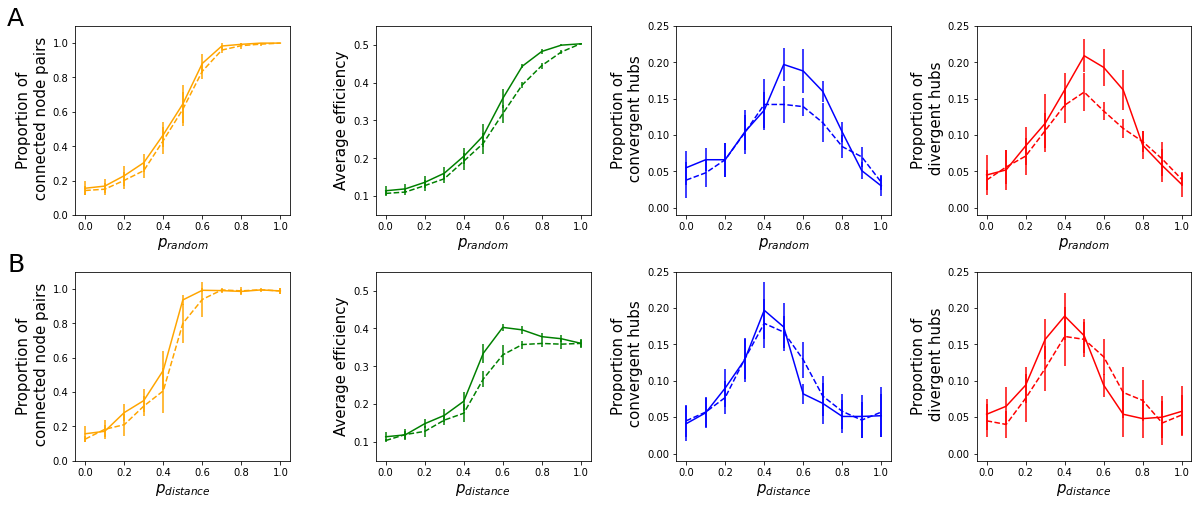

In [13]:
colorsPlot = [ 'orange', 'green','blue','red','cyan']
shapePoint = ['--s','-v','-o','-d','-h']
shapePointNoLine = ['s','v','o','d','h']
plt.rcParams['figure.figsize'] = [20, 8]
K = 10; step = 15000; p_in = 0.5

plt.subplot(2,4,1)
mu = []; sig = []
for p in connected_pairs_rand[p_in].keys():
    cp_temp = np.zeros(K)
    for k in connected_pairs_rand[p_in][p].keys():
        cp_temp[k] = np.sum(connected_pairs_rand[p_in][p][k][step])/10000
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(connected_pairs_rand[p_in].keys(),mu,sig,color=colorsPlot[0])

mu = []; sig = []
for p in connected_pairs_rand_D[p_in].keys():
    cp_temp = np.zeros(K)
    for k in connected_pairs_rand_D[p_in][p].keys():
        cp_temp[k] = np.sum(connected_pairs_rand_D[p_in][p][k][step])/10000
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(connected_pairs_rand_D[p_in].keys(),mu,sig,color=colorsPlot[0],linestyle='--')

plt.xlabel('$p_{random}$',fontsize=15)
plt.ylabel('Proportion of\n connected node pairs',fontsize=15)
plt.ylim([0,1.1])
plt.text(-0.4,1.1,'A',fontsize=25)

plt.subplot(2,4,2)
mu = []; sig = []
for p in rand_D_eff[p_in].keys():
    cp_temp = np.zeros(K)
    for k in rand_D_eff[p_in][p].keys():
        cp_temp[k] = np.sum(rand_D_eff[p_in][p][k][step])
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(rand_D_eff[p_in].keys(),mu,sig,color=colorsPlot[1],linestyle='--')

mu = []; sig = []
for p in rand_eff[p_in].keys():
    cp_temp = np.zeros(K)
    for k in rand_eff[p_in][p].keys():
        cp_temp[k] = np.sum(rand_eff[p_in][p][k][step])
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(rand_eff[p_in].keys(),mu,sig,color=colorsPlot[1])

plt.xlabel('$p_{random}$',fontsize=15)
plt.ylim([0.05,0.55])
plt.ylabel('Average efficiency',fontsize=15)

plt.subplot(2,4,3)
mu = []; sig = []
for p in Hubs_rand_D['in'][p_in].keys():
    in_hubs_temp = np.zeros(K)
    for k in Hubs_rand_D['in'][p_in][p].keys():
        in_hubs_temp[k] = Hubs_rand_D['in'][p_in][p][k][step]/100
    mu.append(np.mean(in_hubs_temp,0))
    sig.append(np.std(in_hubs_temp,0))
plt.errorbar(Hubs_rand_D['in'][p_in].keys(),mu,sig,color=colorsPlot[2],linestyle='--')  

mu = []; sig = []
for p in Hubs_rand['in'][p_in].keys():
    in_hubs_temp = np.zeros(K)
    for k in Hubs_rand['in'][p_in][p].keys():
        in_hubs_temp[k] = Hubs_rand['in'][p_in][p][k][step]/100
    mu.append(np.mean(in_hubs_temp,0))
    sig.append(np.std(in_hubs_temp,0))
plt.errorbar(Hubs_rand['in'][p_in].keys(),mu,sig,color=colorsPlot[2])    
plt.xlabel('$p_{random}$',fontsize=15)
plt.ylabel('Proportion of\n convergent hubs',fontsize=15)
plt.ylim([-0.01,0.25])

plt.subplot(2,4,4)
mu = []; sig = []
for p in Hubs_rand_D['out'][p_in].keys():
    out_hubs_temp = np.zeros(K)
    for k in Hubs_rand_D['out'][p_in][p].keys():
        out_hubs_temp[k] = Hubs_rand_D['out'][p_in][p][k][step]/100
    mu.append(np.mean(out_hubs_temp,0))
    sig.append(np.std(out_hubs_temp,0)) 
plt.errorbar(Hubs_rand_D['out'][p_in].keys(),mu,sig,color=colorsPlot[3],linestyle='--')    

mu = []; sig = []
for p in Hubs_rand['out'][p_in].keys():
    out_hubs_temp = np.zeros(K)
    for k in Hubs_rand['out'][p_in][p].keys():
        out_hubs_temp[k] = Hubs_rand['out'][p_in][p][k][step]/100
    mu.append(np.mean(out_hubs_temp,0))
    sig.append(np.std(out_hubs_temp,0)) 
plt.errorbar(Hubs_rand['out'][p_in].keys(),mu,sig,color=colorsPlot[3])      
plt.ylabel('Proportion of\n divergent hubs',fontsize=15)
plt.xlabel('$p_{random}$',fontsize=15)
plt.ylim([-0.01,0.25])

plt.subplot(2,4,5)
mu = []; sig = []
for p in connected_pairs_dist[p_in].keys():
    cp_temp = np.zeros(K)
    for k in connected_pairs_dist[p_in][p].keys():
        cp_temp[k] = np.sum(connected_pairs_dist[p_in][p][k][step])/10000
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(connected_pairs_dist[p_in].keys(),mu,sig,color=colorsPlot[0])

mu = []; sig = []
for p in connected_pairs_dist_D[p_in].keys():
    cp_temp = np.zeros(K)
    for k in connected_pairs_dist_D[p_in][p].keys():
        cp_temp[k] = np.sum(connected_pairs_dist_D[p_in][p][k][step])/10000
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(connected_pairs_dist_D[p_in].keys(),mu,sig,color=colorsPlot[0],linestyle='--')

plt.xlabel('$p_{distance}$',fontsize=15)
plt.ylabel('Proportion of\n connected node pairs',fontsize=15)
plt.ylim([0,1.1])
plt.text(-0.4,1.1,'B',fontsize=25)

plt.subplot(2,4,6)
mu = []; sig = []
for p in dist_D_eff[p_in].keys():
    cp_temp = np.zeros(K)
    for k in dist_D_eff[p_in][p].keys():
        cp_temp[k] = np.sum(dist_D_eff[p_in][p][k][step])
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(dist_D_eff[p_in].keys(),mu,sig,color=colorsPlot[1],linestyle='--')

mu = []; sig = []
for p in dist_eff[p_in].keys():
    cp_temp = np.zeros(K)
    for k in dist_eff[p_in][p].keys():
        cp_temp[k] = np.sum(dist_eff[p_in][p][k][step])
    mu.append(np.mean(cp_temp))
    sig.append(np.std(cp_temp))
plt.errorbar(dist_eff[p_in].keys(),mu,sig,color=colorsPlot[1])
plt.xlabel('$p_{distance}$',fontsize=15)
plt.ylim([0.05,0.55])
plt.ylabel('Average efficiency',fontsize=15)

plt.subplot(2,4,7)
mu = []; sig = []
for p in Hubs_dist_D['in'][p_in].keys():
    in_hubs_temp = np.zeros(K)
    for k in Hubs_dist_D['in'][p_in][p].keys():
        in_hubs_temp[k] = Hubs_dist_D['in'][p_in][p][k][step]/100
    mu.append(np.mean(in_hubs_temp,0))
    sig.append(np.std(in_hubs_temp,0))
plt.errorbar(Hubs_dist_D['in'][p_in].keys(),mu,sig,color=colorsPlot[2],linestyle='--')  

mu = []; sig = []
for p in Hubs_dist['in'][p_in].keys():
    in_hubs_temp = np.zeros(K)
    for k in Hubs_dist['in'][p_in][p].keys():
        in_hubs_temp[k] = Hubs_dist['in'][p_in][p][k][step]/100
    mu.append(np.mean(in_hubs_temp,0))
    sig.append(np.std(in_hubs_temp,0))
plt.errorbar(Hubs_dist['in'][p_in].keys(),mu,sig,color=colorsPlot[2])    
plt.xlabel('$p_{distance}$',fontsize=15)
plt.ylabel('Proportion of\n convergent hubs',fontsize=15)
plt.ylim([-0.01,0.25])

plt.subplot(2,4,8)
mu = []; sig = []
for p in Hubs_dist_D['out'][p_in].keys():
    out_hubs_temp = np.zeros(K)
    for k in Hubs_dist_D['out'][p_in][p].keys():
        out_hubs_temp[k] = Hubs_dist_D['out'][p_in][p][k][step]/100
    mu.append(np.mean(out_hubs_temp,0))
    sig.append(np.std(out_hubs_temp,0)) 
plt.errorbar(Hubs_dist_D['out'][p_in].keys(),mu,sig,color=colorsPlot[3],linestyle='--')    

mu = []; sig = []
for p in Hubs_dist['out'][p_in].keys():
    out_hubs_temp = np.zeros(K)
    for k in Hubs_dist['out'][p_in][p].keys():
        out_hubs_temp[k] = Hubs_dist['out'][p_in][p][k][step]/100
    mu.append(np.mean(out_hubs_temp,0))
    sig.append(np.std(out_hubs_temp,0)) 
plt.errorbar(Hubs_dist['out'][p_in].keys(),mu,sig,color=colorsPlot[3])      
plt.ylabel('Proportion of\n divergent hubs',fontsize=15)
plt.xlabel('$p_{distance}$',fontsize=15)
plt.ylim([-0.01,0.25])

plt.subplots_adjust(wspace=0.4,hspace=0.3)


### Fig S6.2: Network measure vs step

In [4]:
K = 10; p_in = 0.5
p_list = [0.2, 0.5, 0.7]
cp_prop_stat = {}; eff = {}; in_hubs = {}; out_hubs = {}

In [7]:
cp_prop_stat['rand'] = {}
eff['rand'] = {}
in_hubs['rand'] = {}
out_hubs['rand'] = {}
for p in p_list:
    cp_prop_stat['rand'][p] = np.zeros((2,31))
    eff['rand'][p] = np.zeros((2,31))
    in_hubs['rand'][p] = np.zeros((2,31))
    out_hubs['rand'][p] = np.zeros((2,31))
        
    cp_prop_temp = np.zeros((K,31))
    eff_temp = np.zeros((K,31))
    in_hubs_temp = np.zeros((K,31))
    out_hubs_temp = np.zeros((K,31))
        
    for k in range(K):
        for step_ind,step in enumerate(connected_pairs_rand[p_in][p][k].keys()):        
            cp_prop_temp[k,step_ind] = np.sum(connected_pairs_rand[p_in][p][k][step])/10000
            eff_temp[k,step_ind] = rand_eff[p_in][p][k][step]
            in_hubs_temp[k,step_ind] = Hubs_rand['in'][p_in][p][k][step]/100
            out_hubs_temp[k,step_ind] = Hubs_rand['out'][p_in][p][k][step]/100

        cp_prop_stat['rand'][p][0,:] = np.mean(cp_prop_temp,0)
        cp_prop_stat['rand'][p][1,:] = np.std(cp_prop_temp,0)    
        eff['rand'][p][0,:] = np.mean(eff_temp,0)
        eff['rand'][p][1,:] = np.std(eff_temp,0)
        in_hubs['rand'][p][0,:] = np.mean(in_hubs_temp,0)
        in_hubs['rand'][p][1,:] = np.std(in_hubs_temp,0)  
        out_hubs['rand'][p][0,:] = np.mean(out_hubs_temp,0)
        out_hubs['rand'][p][1,:] = np.std(out_hubs_temp,0)

In [8]:
cp_prop_stat['dist'] = {}
eff['dist'] = {}
in_hubs['dist'] = {}
out_hubs['dist'] = {}
for p in p_list:
    cp_prop_stat['dist'][p] = np.zeros((2,31))
    eff['dist'][p] = np.zeros((2,31))
    in_hubs['dist'][p] = np.zeros((2,31))
    out_hubs['dist'][p] = np.zeros((2,31))
        
    cp_prop_temp = np.zeros((K,31))
    eff_temp = np.zeros((K,31))
    in_hubs_temp = np.zeros((K,31))
    out_hubs_temp = np.zeros((K,31))
        
    for k in range(K):
        for step_ind,step in enumerate(connected_pairs_dist[p_in][p][k].keys()):        
            cp_prop_temp[k,step_ind] = np.sum(connected_pairs_dist[p_in][p][k][step])/10000
            eff_temp[k,step_ind] = dist_eff[p_in][p][k][step]
            in_hubs_temp[k,step_ind] = Hubs_dist['in'][p_in][p][k][step]/100
            out_hubs_temp[k,step_ind] = Hubs_dist['out'][p_in][p][k][step]/100

        cp_prop_stat['dist'][p][0,:] = np.mean(cp_prop_temp,0)
        cp_prop_stat['dist'][p][1,:] = np.std(cp_prop_temp,0)    
        eff['dist'][p][0,:] = np.mean(eff_temp,0)
        eff['dist'][p][1,:] = np.std(eff_temp,0)
        in_hubs['dist'][p][0,:] = np.mean(in_hubs_temp,0)
        in_hubs['dist'][p][1,:] = np.std(in_hubs_temp,0)  
        out_hubs['dist'][p][0,:] = np.mean(out_hubs_temp,0)
        out_hubs['dist'][p][1,:] = np.std(out_hubs_temp,0)

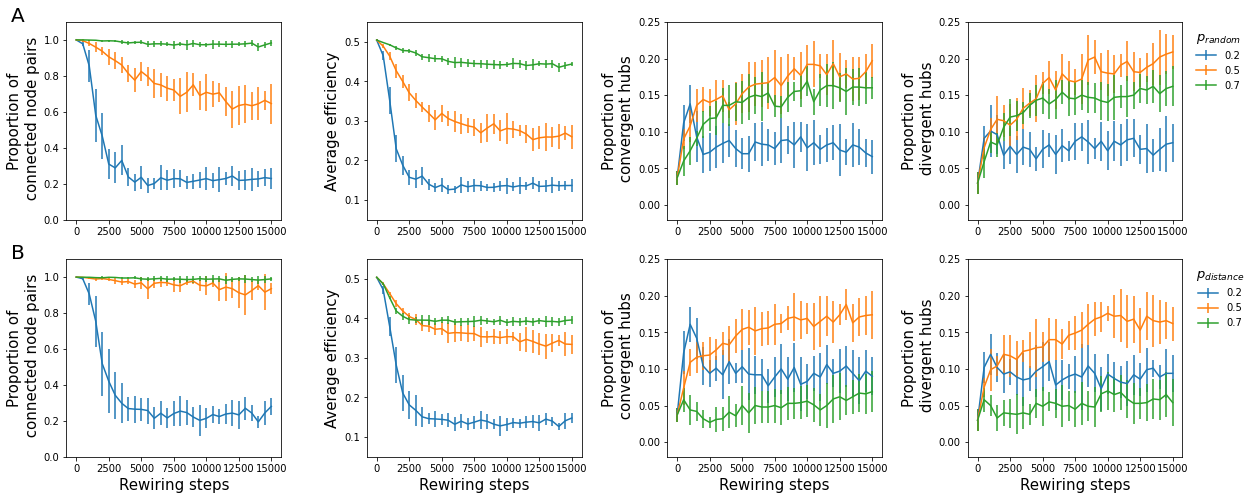

In [10]:
colorsPlot = [ 'orange', 'green','blue','red','cyan']
shapePoint = ['--s','-v','-o','-d','-h']
shapePointNoLine = ['s','v','o','d','h']
plt.rcParams['figure.figsize'] = [20, 8]
K = 10; step = 15000

plt.subplot(2,4,1)
for p in p_list:
    plt.errorbar(connected_pairs_rand[p_in][p][0].keys(),cp_prop_stat['rand'][p][0,:],cp_prop_stat['rand'][p][1,:],
                     label=str(p))
plt.ylim([0,1.1])
plt.ylabel('Proportion of\n connected node pairs',fontsize=15)
plt.text(-5000,1.1,'A',fontsize=20)

plt.subplot(2,4,2)
for p in p_list:
    plt.errorbar(rand_eff[p_in][p][0].keys(),eff['rand'][p][0,:],eff['rand'][p][1,:],label=str(p))
plt.ylim([0.05,0.55])
plt.ylabel('Average efficiency',fontsize=15)

plt.subplot(2,4,3)
for p in p_list:
    plt.errorbar(Hubs_rand['in'][p_in][p][0].keys(),in_hubs['rand'][p][0,:],in_hubs['rand'][p][1,:],label=str(p))
plt.ylim([-0.02,0.25])
plt.ylabel('Proportion of\n convergent hubs',fontsize=15)

plt.subplot(2,4,4)
for p in p_list:
    plt.errorbar(Hubs_rand['out'][p_in][p][0].keys(),out_hubs['rand'][p][0,:],out_hubs['rand'][p][1,:],label=str(p))
plt.ylim([-0.02,0.25])
plt.ylabel('Proportion of\n divergent hubs',fontsize=15)
plt.legend(title='$p_{random}$',frameon=False,title_fontsize=13,loc='upper left',bbox_to_anchor=(1.02, 1))

plt.subplot(2,4,5)
for p in p_list:
    plt.errorbar(connected_pairs_dist[p_in][p][0].keys(),cp_prop_stat['dist'][p][0,:],cp_prop_stat['dist'][p][1,:],
                     label=str(p))
plt.ylim([0,1.1])
plt.ylabel('Proportion of\n connected node pairs',fontsize=15)
plt.text(-5000,1.1,'B',fontsize=20)
plt.xlabel('Rewiring steps', fontsize=15)

plt.subplot(2,4,6)
for p in p_list:
    plt.errorbar(dist_eff[p_in][p][0].keys(),eff['dist'][p][0,:],eff['dist'][p][1,:],label=str(p))
plt.ylim([0.05,0.55])
plt.ylabel('Average efficiency',fontsize=15)
plt.xlabel('Rewiring steps', fontsize=15)

plt.subplot(2,4,7)
for p in p_list:
    plt.errorbar(Hubs_dist['in'][p_in][p][0].keys(),in_hubs['dist'][p][0,:],in_hubs['dist'][p][1,:],label=str(p))
plt.ylim([-0.02,0.25])
plt.ylabel('Proportion of\n convergent hubs',fontsize=15)
plt.xlabel('Rewiring steps', fontsize=15)

plt.subplot(2,4,8)
for p in p_list:
    plt.errorbar(Hubs_dist['out'][p_in][p][0].keys(),out_hubs['dist'][p][0,:],out_hubs['dist'][p][1,:],label=str(p))
plt.ylim([-0.02,0.25])
plt.ylabel('Proportion of\n divergent hubs',fontsize=15)
plt.xlabel('Rewiring steps', fontsize=15)
plt.legend(title='$p_{distance}$',frameon=False,title_fontsize=13,loc='upper left',bbox_to_anchor=(1.02, 1))

plt.subplots_adjust(wspace=0.4)


### Fig S6.3: Stability of cd-units, #cd-units, #source and target nodes, size and density of intermediate subgraph

In [2]:
fname = '../Output/Stoch/rand_num_cd.pckl'
f = open(fname, 'rb')
rand_num_cd = pickle.load(f)
f.close()

fname = '../Output/Stoch/rand_num_sour.pckl'
f = open(fname, 'rb')
rand_num_sour = pickle.load(f)
f.close()

fname = '../Output/Stoch/rand_num_targ.pckl'
f = open(fname, 'rb')
rand_num_targ = pickle.load(f)
f.close()

fname = '../Output/Stoch/rand_prop_ovl.pckl'
f = open(fname, 'rb')
rand_prop_overlap = pickle.load(f)
f.close()

fname = '../Output/Stoch/rand_interm_size.pckl'
f = open(fname, 'rb')
rand_interm_size = pickle.load(f)
f.close()

fname = '../Output/Stoch/rand_interm_density.pckl'
f = open(fname, 'rb')
rand_interm_density = pickle.load(f)
f.close()

In [3]:
fname = '../Output/Determ/rand_num_cd.pckl'
f = open(fname, 'rb')
rand_D_num_cd = pickle.load(f)
f.close()

fname = '../Output/Determ/rand_num_sour.pckl'
f = open(fname, 'rb')
rand_D_num_sour = pickle.load(f)
f.close()

fname = '../Output/Determ/rand_num_targ.pckl'
f = open(fname, 'rb')
rand_D_num_targ = pickle.load(f)
f.close()

fname = '../Output/Determ/rand_prop_ovl.pckl'
f = open(fname, 'rb')
rand_D_prop_overlap = pickle.load(f)
f.close()

fname = '../Output/Determ/rand_interm_size.pckl'
f = open(fname, 'rb')
rand_D_interm_size = pickle.load(f)
f.close()

fname = '../Output/Determ/rand_interm_density.pckl'
f = open(fname, 'rb')
rand_D_interm_density = pickle.load(f)
f.close()

In [4]:
fname = '../Output/Stoch/dist_num_cd.pckl'
f = open(fname, 'rb')
dist_num_cd = pickle.load(f)
f.close()

fname = '../Output/Stoch/dist_num_sour.pckl'
f = open(fname, 'rb')
dist_num_sour = pickle.load(f)
f.close()

fname = '../Output/Stoch/dist_num_targ.pckl'
f = open(fname, 'rb')
dist_num_targ = pickle.load(f)
f.close()

fname = '../Output/Stoch/dist_prop_ovl.pckl'
f = open(fname, 'rb')
dist_prop_overlap = pickle.load(f)
f.close()

fname = '../Output/Stoch/dist_interm_size.pckl'
f = open(fname, 'rb')
dist_interm_size = pickle.load(f)
f.close()

fname = '../Output/Stoch/dist_interm_density.pckl'
f = open(fname, 'rb')
dist_interm_density = pickle.load(f)
f.close()

In [5]:
fname = '../Output/Determ/dist_num_cd.pckl'
f = open(fname, 'rb')
dist_D_num_cd = pickle.load(f)
f.close()

fname = '../Output/Determ/dist_num_sour.pckl'
f = open(fname, 'rb')
dist_D_num_sour = pickle.load(f)
f.close()

fname = '../Output/Determ/dist_num_targ.pckl'
f = open(fname, 'rb')
dist_D_num_targ = pickle.load(f)
f.close()

fname = '../Output/Determ/dist_prop_ovl.pckl'
f = open(fname, 'rb')
dist_D_prop_overlap = pickle.load(f)
f.close()

fname = '../Output/Determ/dist_interm_size.pckl'
f = open(fname, 'rb')
dist_D_interm_size = pickle.load(f)
f.close()

fname = '../Output/Determ/dist_interm_density.pckl'
f = open(fname, 'rb')
dist_D_interm_density = pickle.load(f)
f.close()

In [6]:
p_list = list(map(lambda x: x/10,range(11)))
thresh = 15; K = 10
ind_list = [500*i for i in range(31)]

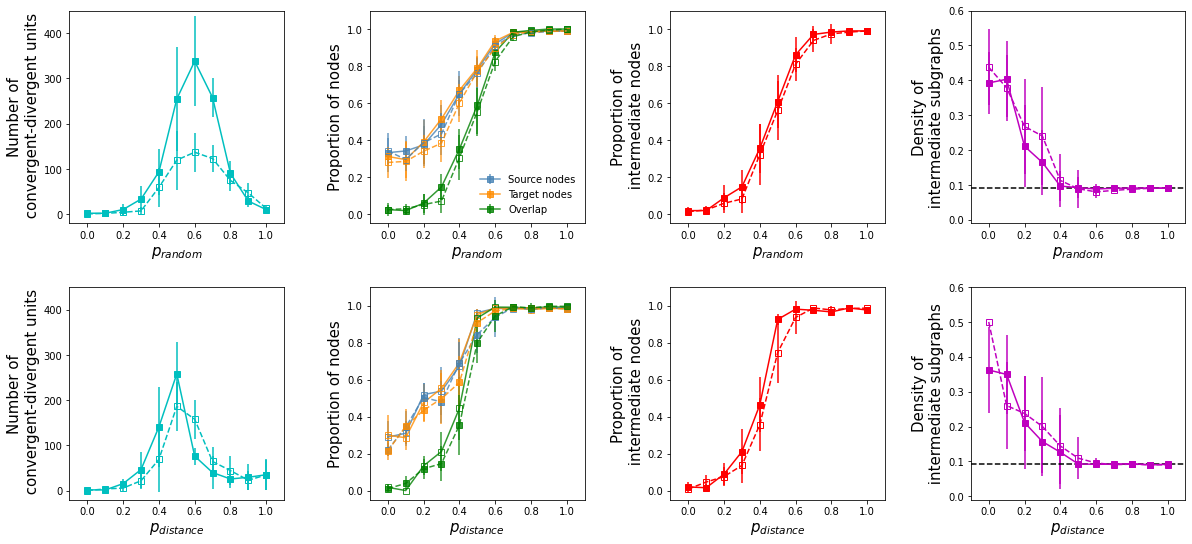

In [10]:
plt.rcParams['figure.figsize'] = [20,9]
plt.subplot(2,4,1)
plt.errorbar(p_list, rand_num_cd[thresh][0,:], rand_num_cd[thresh][1,:],
             mfc='c', mec='c', 
             marker='s', color='c')
plt.errorbar(p_list, rand_D_num_cd[thresh][0,:], rand_D_num_cd[thresh][1,:],
             mfc='c', mec='c', fillstyle='none',
             marker='s', color='c',linestyle='--')
plt.xlabel('$p_{random}$',fontsize=15)
plt.ylabel('Number of\n convergent-divergent units',fontsize=15)
plt.xlim([-0.1,1.1])
plt.ylim([-20,450])

plt.subplot(2,4,2)
mu_sour = []; sig_sour = []
mu_targ = []; sig_targ = []
mu_ovl = []; sig_ovl = []
for p in p_list:
    mu_sour.append(np.nanmean(rand_num_sour[thresh][p]/99))
    sig_sour.append(np.nanstd(rand_num_sour[thresh][p]/99))
    mu_targ.append(np.nanmean(rand_num_targ[thresh][p]/99))
    sig_targ.append(np.nanstd(rand_num_targ[thresh][p]/99))
    mu_ovl.append(np.nanmean(rand_prop_overlap[thresh][p]))
    sig_ovl.append(np.nanstd(rand_prop_overlap[thresh][p]))
plt.errorbar(p_list,mu_sour,sig_sour,marker='s', color='steelblue',alpha=0.8,
             label='Source nodes')
plt.errorbar(p_list,mu_targ,sig_targ,marker='s',color='darkorange',alpha=0.8,
             label='Target nodes')
plt.errorbar(p_list,mu_ovl,sig_ovl,marker='s',color='g',alpha=0.8,
             label='Overlap')
plt.legend(frameon=False,loc='lower right')

mu_sour = []; sig_sour = []
mu_targ = []; sig_targ = []
mu_ovl = []; sig_ovl = []
for p in p_list:
    mu_sour.append(np.nanmean(rand_D_num_sour[thresh][p]/99))
    sig_sour.append(np.nanstd(rand_D_num_sour[thresh][p]/99))
    mu_targ.append(np.nanmean(rand_D_num_targ[thresh][p]/99))
    sig_targ.append(np.nanstd(rand_D_num_targ[thresh][p]/99))
    mu_ovl.append(np.nanmean(rand_D_prop_overlap[thresh][p]))
    sig_ovl.append(np.nanstd(rand_D_prop_overlap[thresh][p]))
plt.errorbar(p_list,mu_sour,sig_sour,marker='s', color='steelblue',alpha=0.8, linestyle='--',fillstyle='none',
             label='Source nodes')
plt.errorbar(p_list,mu_targ,sig_targ,marker='s',color='darkorange',alpha=0.8, linestyle='--',fillstyle='none',
             label='Target nodes')
plt.errorbar(p_list,mu_ovl,sig_ovl,marker='s',color='g',alpha=0.8, linestyle='--',fillstyle='none',
             label='Overlap')

plt.xlabel('$p_{random}$',fontsize=15)
plt.ylabel('Proportion of nodes',fontsize=15)
plt.xlim([-0.1,1.1])
plt.ylim([-0.05,1.1])

plt.subplot(2,4,3)
mu_nor = []; sig_nor = []
for p in p_list:
    size_nor_temp = []
    for k in rand_interm_size[thresh][p].keys():
        if ~np.all(np.isnan(rand_interm_size[thresh][p][k])):
            size_nor_temp=size_nor_temp+rand_interm_size[thresh][p][k]#[k] = np.nanmean(rand_interm_size['nor'][p][k])
    mu_nor.append(np.nanmean(size_nor_temp)/99)
    sig_nor.append(np.nanstd(size_nor_temp)/99)
plt.errorbar(p_list,mu_nor,sig_nor,
             mfc='r', mec='r', 
        marker='s', color='r')

mu_nor = []; sig_nor = []
for p in p_list:
    size_nor_temp = []
    for k in rand_D_interm_size[thresh][p].keys():
        if ~np.all(np.isnan(rand_D_interm_size[thresh][p][k])):
            size_nor_temp=size_nor_temp+rand_D_interm_size[thresh][p][k]#[k] = np.nanmean(rand_interm_size['nor'][p][k])
    mu_nor.append(np.nanmean(size_nor_temp)/99)
    sig_nor.append(np.nanstd(size_nor_temp)/99)
plt.errorbar(p_list,mu_nor,sig_nor,
             mfc='r', mec='r', fillstyle='none',
        marker='s',linestyle='--', color='r')
plt.xlabel('$p_{random}$',fontsize=15)
plt.ylabel('Proportion of\n intermediate nodes',fontsize=15)
plt.xlim([-0.1,1.1])
plt.ylim([-0.05,1.1])

plt.subplot(2,4,4)
p_nor = []; mu_nor = []; sig_nor = []
for p in p_list:
    density_nor_temp = []
    for k in rand_interm_density[thresh][p].keys():
        if ~np.all(np.isnan(rand_interm_density[thresh][p][k])):
            density_nor_temp=density_nor_temp+rand_interm_density[thresh][p][k]
    if ~np.all(np.isnan(density_nor_temp)):           
        mu_nor.append(np.nanmean(density_nor_temp))
        sig_nor.append(np.nanstd(density_nor_temp))
        p_nor.append(p)
plt.errorbar(p_nor,mu_nor,sig_nor,
             mfc='m', mec='m', 
        marker='s', color='m')
p_nor = []; mu_nor = []; sig_nor = []
for p in p_list:
    density_nor_temp = []
    for k in rand_D_interm_density[thresh][p].keys():
        if ~np.all(np.isnan(rand_D_interm_density[thresh][p][k])):
            density_nor_temp=density_nor_temp+rand_D_interm_density[thresh][p][k]
    if ~np.all(np.isnan(density_nor_temp)):           
        mu_nor.append(np.nanmean(density_nor_temp))
        sig_nor.append(np.nanstd(density_nor_temp))
        p_nor.append(p)
plt.errorbar(p_nor,mu_nor,sig_nor,
             mfc='m', mec='m', fillstyle='none',
        marker='s', color='m',linestyle='--')
plt.xlabel('$p_{random}$',fontsize=15)
plt.ylabel('Density of\n intermediate subgraphs ',fontsize=15)
plt.axhline(912/9900,color='k',ls='--')
plt.xlim([-0.1,1.1])
plt.ylim([-0.01,0.6])

plt.subplot(2,4,5)
plt.errorbar(p_list, dist_num_cd[thresh][0,:], dist_num_cd[thresh][1,:],
             mfc='c', mec='c', 
             marker='s', color='c')
plt.errorbar(p_list, dist_D_num_cd[thresh][0,:], dist_D_num_cd[thresh][1,:],
             mfc='c', mec='c', fillstyle='none',
             marker='s', color='c',linestyle='--')
plt.xlabel('$p_{distance}$',fontsize=15)
plt.ylabel('Number of\n convergent-divergent units',fontsize=15)
plt.xlim([-0.1,1.1])
plt.ylim([-20,450])

plt.subplot(2,4,6)
mu_sour = []; sig_sour = []
mu_targ = []; sig_targ = []
mu_ovl = []; sig_ovl = []
for p in p_list:
    mu_sour.append(np.nanmean(dist_num_sour[thresh][p]/99))
    sig_sour.append(np.nanstd(dist_num_sour[thresh][p]/99))
    mu_targ.append(np.nanmean(dist_num_targ[thresh][p]/99))
    sig_targ.append(np.nanstd(dist_num_targ[thresh][p]/99))
    mu_ovl.append(np.nanmean(dist_prop_overlap[thresh][p]))
    sig_ovl.append(np.nanstd(dist_prop_overlap[thresh][p]))
plt.errorbar(p_list,mu_sour,sig_sour,marker='s', color='steelblue',alpha=0.8, fillstyle='none',
             label='Source nodes')
plt.errorbar(p_list,mu_targ,sig_targ,marker='s',color='darkorange',alpha=0.8, fillstyle='none',
             label='Target nodes')
plt.errorbar(p_list,mu_ovl,sig_ovl,marker='s',color='g',alpha=0.8, fillstyle='none',
             label='Overlap')

mu_sour = []; sig_sour = []
mu_targ = []; sig_targ = []
mu_ovl = []; sig_ovl = []
for p in p_list:
    mu_sour.append(np.nanmean(dist_D_num_sour[thresh][p]/99))
    sig_sour.append(np.nanstd(dist_D_num_sour[thresh][p]/99))
    mu_targ.append(np.nanmean(dist_D_num_targ[thresh][p]/99))
    sig_targ.append(np.nanstd(dist_D_num_targ[thresh][p]/99))
    mu_ovl.append(np.nanmean(dist_D_prop_overlap[thresh][p]))
    sig_ovl.append(np.nanstd(dist_D_prop_overlap[thresh][p]))
plt.errorbar(p_list,mu_sour,sig_sour,marker='s', color='steelblue',alpha=0.8, linestyle='--',
             label='Source nodes')
plt.errorbar(p_list,mu_targ,sig_targ,marker='s',color='darkorange',alpha=0.8, linestyle='--',
             label='Target nodes')
plt.errorbar(p_list,mu_ovl,sig_ovl,marker='s',color='g',alpha=0.8, linestyle='--',
             label='Overlap')
plt.xlabel('$p_{distance}$',fontsize=15)
plt.ylabel('Proportion of nodes',fontsize=15)
plt.xlim([-0.1,1.1])
plt.ylim([-0.05,1.1])

plt.subplot(2,4,7)
mu_nor = []; sig_nor = []
for p in p_list:
    size_nor_temp = []
    for k in dist_interm_size[thresh][p].keys():
        if ~np.all(np.isnan(dist_interm_size[thresh][p][k])):
            size_nor_temp=size_nor_temp+dist_interm_size[thresh][p][k]#[k] = np.nanmean(dist_interm_size['nor'][p][k])
    mu_nor.append(np.nanmean(size_nor_temp)/99)
    sig_nor.append(np.nanstd(size_nor_temp)/99)
plt.errorbar(p_list,mu_nor,sig_nor,
             mfc='r', mec='r', 
        marker='s', color='r')
mu_nor = []; sig_nor = []
for p in p_list:
    size_nor_temp = []
    for k in dist_D_interm_size[thresh][p].keys():
        if ~np.all(np.isnan(dist_D_interm_size[thresh][p][k])):
            size_nor_temp=size_nor_temp+dist_D_interm_size[thresh][p][k]#[k] = np.nanmean(dist_interm_size['nor'][p][k])
    mu_nor.append(np.nanmean(size_nor_temp)/99)
    sig_nor.append(np.nanstd(size_nor_temp)/99)
plt.errorbar(p_list,mu_nor,sig_nor,
             mfc='r', mec='r', fillstyle='none',
        marker='s',linestyle='--', color='r')
plt.xlabel('$p_{distance}$',fontsize=15)
plt.ylabel('Proportion of\n intermediate nodes',fontsize=15)
plt.xlim([-0.1,1.1])
plt.ylim([-0.05,1.1])

plt.subplot(2,4,8)
p_nor = []; mu_nor = []; sig_nor = []
for p in p_list:
    density_nor_temp = []
    for k in dist_interm_density[thresh][p].keys():
        if ~np.all(np.isnan(dist_interm_density[thresh][p][k])):
            density_nor_temp=density_nor_temp+dist_interm_density[thresh][p][k]
    if ~np.all(np.isnan(density_nor_temp)):           
        mu_nor.append(np.nanmean(density_nor_temp))
        sig_nor.append(np.nanstd(density_nor_temp))
        p_nor.append(p)
plt.errorbar(p_nor,mu_nor,sig_nor,
             mfc='m', mec='m', 
        marker='s', color='m',
             label='Interm')
p_nor = []; mu_nor = []; sig_nor = []
for p in p_list:
    density_nor_temp = []
    for k in dist_D_interm_density[thresh][p].keys():
        if ~np.all(np.isnan(dist_D_interm_density[thresh][p][k])):
            density_nor_temp=density_nor_temp+dist_D_interm_density[thresh][p][k]
    if ~np.all(np.isnan(density_nor_temp)):           
        mu_nor.append(np.nanmean(density_nor_temp))
        sig_nor.append(np.nanstd(density_nor_temp))
        p_nor.append(p)
plt.errorbar(p_nor,mu_nor,sig_nor,
             mfc='m', mec='m', fillstyle='none',
        marker='s', color='m',linestyle='--')
plt.xlabel('$p_{distance}$',fontsize=15)
plt.ylabel('Density of\n intermediate subgraphs ',fontsize=15)
plt.axhline(912/9900,color='k',ls='--')
plt.xlim([-0.1,1.1])
plt.ylim([-0.01,0.6])

plt.subplots_adjust(wspace=0.4, hspace=0.3)
